# Caso completo: estabilidad del caso minoritario con SMOTE + GLM, Decision Tree y Random Forest

Este notebook construye un caso completo de clasificación binaria con clase minoritaria. El objetivo es comprobar cómo cambia la estabilidad y la capacidad predictiva sobre la clase minoritaria al aplicar **SMOTE** únicamente sobre el conjunto de entrenamiento.

Modelos comparados:

1. GLM / Regresión logística.
2. Árbol de decisión.
3. Random Forest.

La idea principal es que, en problemas desbalanceados, la accuracy suele ser engañosa. Por eso miraremos especialmente recall, precision, F1, ROC-AUC, PR-AUC y matrices de confusión.

In [5]:
# ============================================================
# 1. Librerías
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score, accuracy_score,
    classification_report
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Creación de un dataset desbalanceado

Simulamos un caso parecido a fraude, impago o detección de riesgo. La clase 1 representa el caso minoritario.

In [6]:
X, y = make_classification(
    n_samples=5000,
    n_features=12,
    n_informative=7,
    n_redundant=3,
    n_clusters_per_class=2,
    weights=[0.92, 0.08],
    class_sep=0.85,
    flip_y=0.02,
    random_state=RANDOM_STATE
)

feature_names = [f"variable_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

df.head()


,variable_1,variable_2,variable_3,variable_4,variable_5,variable_6,variable_7,variable_8,variable_9,variable_10,variable_11,variable_12,target
0,3.196564,1.897489,-1.665196,-2.045616,-0.470790,-0.274343,0.017423,1.326455,-1.474652,-1.586147,-1.149368,-0.664103,0
1,-0.736517,1.097884,0.306586,-1.882987,1.336823,-1.094746,0.649744,-1.237692,-0.445489,1.180152,1.547531,-0.771847,0
2,-0.406175,0.750005,-1.620048,0.760425,-1.371766,3.250213,0.681114,-0.036475,-0.283539,-5.374009,1.914166,-3.414459,0
3,-3.301075,1.458001,-2.777292,2.520623,-1.595437,2.756657,1.376331,-0.565376,-0.081130,-4.924337,3.955201,-6.860808,0
4,3.966309,4.068332,-1.131594,1.979029,-0.942306,-0.054461,-0.137139,1.155774,-1.734912,-2.265628,-0.562618,-1.458360,1


In [7]:
resumen_clases = pd.DataFrame({
    "frecuencia": df["target"].value_counts().sort_index(),
    "porcentaje": (df["target"].value_counts(normalize=True).sort_index() * 100).round(2)
})
resumen_clases


,frecuencia,porcentaje
target,,
0,4559,91.18
1,441,8.82


## 3. División train/test estratificada

SMOTE debe aplicarse **después** de separar train y test. Si se aplica antes, contaminamos el test.

In [8]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(4))
print("Distribución en test:")
print(y_test.value_counts(normalize=True).round(4))


Distribución en entrenamiento:
target
0    0.9117
1    0.0883
Name: proportion, dtype: float64
Distribución en test:
target
0    0.912
1    0.088
Name: proportion, dtype: float64


## 4. Funciones de evaluación

In [9]:
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    """Entrena un modelo y devuelve métricas sobre test."""
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    metricas = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_minoritario": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall_minoritario": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1_minoritario": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob)
    }
    return metricas, y_pred, y_prob


def mostrar_matriz_confusion(y_test, y_pred, titulo):
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm)
    ax.set_title(titulo)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()


## 5. Modelos sin SMOTE

In [10]:
modelos_sin_smote = {
    "GLM / Regresión logística - sin SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree - sin SMOTE": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=30, random_state=RANDOM_STATE
    ),
    "Random Forest - sin SMOTE": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

resultados = []
predicciones = {}

for nombre, modelo in modelos_sin_smote.items():
    metricas, y_pred, y_prob = evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados.append(metricas)
    predicciones[nombre] = (y_pred, y_prob)

pd.DataFrame(resultados).round(4)


,modelo,accuracy,precision_minoritario,recall_minoritario,f1_minoritario,roc_auc,pr_auc
0,GLM / Regresión logística - sin SMOTE,0.9273,0.8108,0.2273,0.3550,0.7761,0.4539
1,Decision Tree - sin SMOTE,0.9287,0.6812,0.3561,0.4677,0.8362,0.4448
2,Random Forest - sin SMOTE,0.9400,0.9375,0.3409,0.5000,0.9005,0.6977


## 6. Aplicación de SMOTE

SMOTE genera observaciones sintéticas de la clase minoritaria en el conjunto de entrenamiento.

In [11]:
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Antes de SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

print("Después de SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(pd.Series(y_train_smote).value_counts(normalize=True).round(4))


Antes de SMOTE:
target
0    3191
1     309
Name: count, dtype: int64
target
0    0.9117
1    0.0883
Name: proportion, dtype: float64
Después de SMOTE:
target
0    3191
1    3191
Name: count, dtype: int64
target
0    0.5
1    0.5
Name: proportion, dtype: float64


## 7. Modelos con SMOTE

In [12]:
modelos_con_smote = {
    "GLM / Regresión logística - con SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree - con SMOTE": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=30, random_state=RANDOM_STATE
    ),
    "Random Forest - con SMOTE": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

for nombre, modelo in modelos_con_smote.items():
    metricas, y_pred, y_prob = evaluar_modelo(nombre, modelo, X_train_smote, y_train_smote, X_test, y_test)
    resultados.append(metricas)
    predicciones[nombre] = (y_pred, y_prob)

tabla_resultados = pd.DataFrame(resultados).round(4)
tabla_resultados


,modelo,accuracy,precision_minoritario,recall_minoritario,f1_minoritario,roc_auc,pr_auc
0,GLM / Regresión logística - sin SMOTE,0.9273,0.8108,0.2273,0.3550,0.7761,0.4539
1,Decision Tree - sin SMOTE,0.9287,0.6812,0.3561,0.4677,0.8362,0.4448
2,Random Forest - sin SMOTE,0.9400,0.9375,0.3409,0.5000,0.9005,0.6977
3,GLM / Regresión logística - con SMOTE,0.7680,0.2273,0.6818,0.3409,0.7919,0.3969
4,Decision Tree - con SMOTE,0.8367,0.3218,0.7727,0.4543,0.8619,0.5808
5,Random Forest - con SMOTE,0.9273,0.5642,0.7652,0.6495,0.9131,0.7464


## 8. Comparación directa antes/después de SMOTE

La mejora más importante debería observarse en el **recall** y el **F1-score** de la clase minoritaria.

In [13]:
tabla_comparacion = tabla_resultados.sort_values(by="f1_minoritario", ascending=False)
tabla_comparacion


,modelo,accuracy,precision_minoritario,recall_minoritario,f1_minoritario,roc_auc,pr_auc
5,Random Forest - con SMOTE,0.9273,0.5642,0.7652,0.6495,0.9131,0.7464
2,Random Forest - sin SMOTE,0.9400,0.9375,0.3409,0.5000,0.9005,0.6977
1,Decision Tree - sin SMOTE,0.9287,0.6812,0.3561,0.4677,0.8362,0.4448
4,Decision Tree - con SMOTE,0.8367,0.3218,0.7727,0.4543,0.8619,0.5808
0,GLM / Regresión logística - sin SMOTE,0.9273,0.8108,0.2273,0.3550,0.7761,0.4539
3,GLM / Regresión logística - con SMOTE,0.7680,0.2273,0.6818,0.3409,0.7919,0.3969


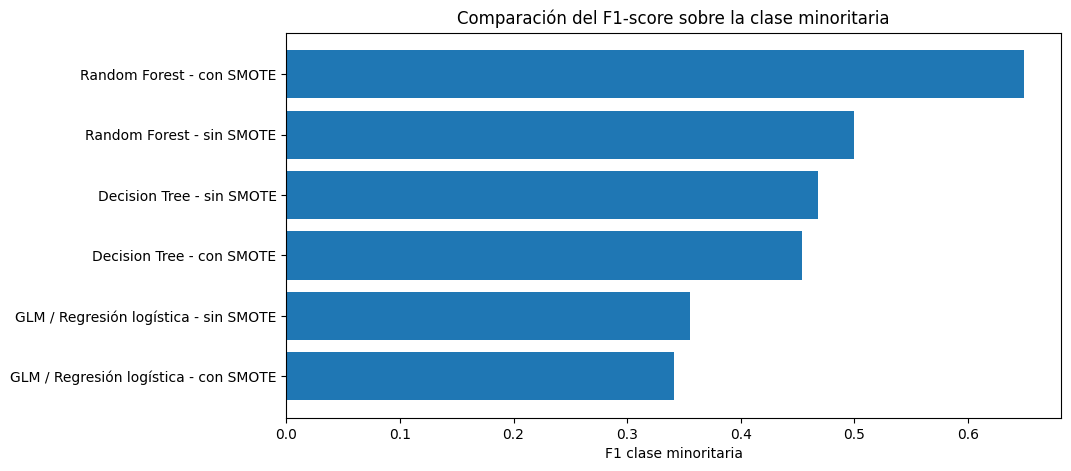

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(tabla_comparacion["modelo"], tabla_comparacion["f1_minoritario"])
ax.set_xlabel("F1 clase minoritaria")
ax.set_title("Comparación del F1-score sobre la clase minoritaria")
plt.gca().invert_yaxis()
plt.show()


## 9. Matrices de confusión

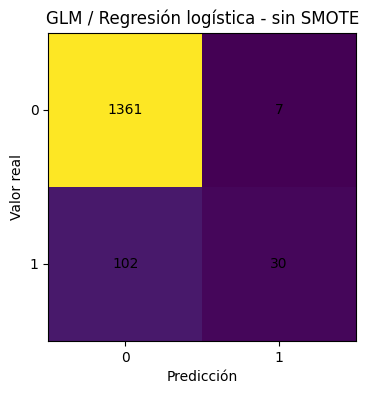

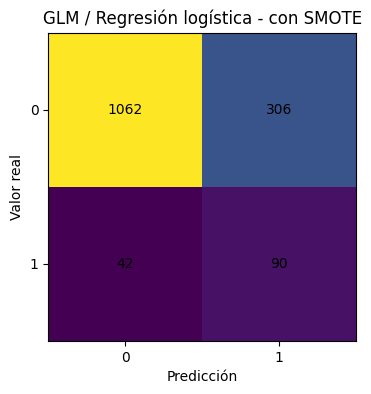

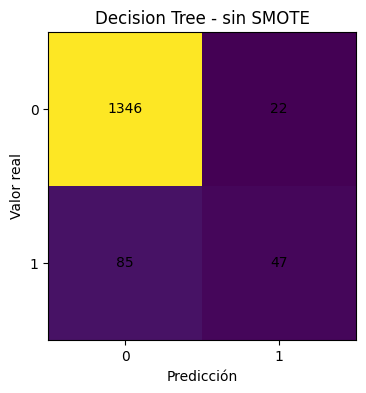

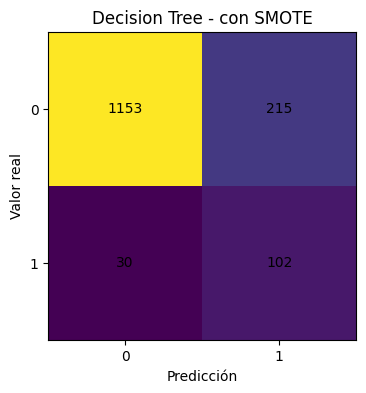

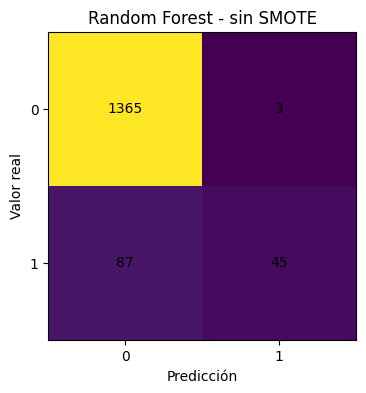

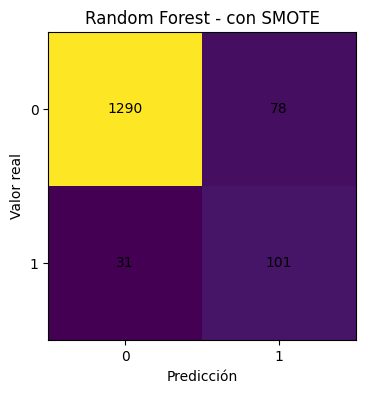

In [15]:
for nombre in [
    "GLM / Regresión logística - sin SMOTE",
    "GLM / Regresión logística - con SMOTE",
    "Decision Tree - sin SMOTE",
    "Decision Tree - con SMOTE",
    "Random Forest - sin SMOTE",
    "Random Forest - con SMOTE"
]:
    y_pred, _ = predicciones[nombre]
    mostrar_matriz_confusion(y_test, y_pred, nombre)


## 10. Estabilidad del caso minoritario mediante validación cruzada

Para hablar de estabilidad no basta con mirar un único test. SMOTE debe aplicarse dentro de cada fold mediante `imblearn.pipeline.Pipeline`.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "precision_minoritario": "precision",
    "recall_minoritario": "recall",
    "f1_minoritario": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

modelos_cv = {
    "GLM sin SMOTE": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "GLM con SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree sin SMOTE": DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=30, random_state=RANDOM_STATE
    ),
    "Decision Tree con SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(max_depth=5, min_samples_leaf=30, random_state=RANDOM_STATE))
    ]),
    "Random Forest sin SMOTE": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Random Forest con SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=15,
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
}

filas_cv = []
for nombre, modelo in modelos_cv.items():
    scores = cross_validate(
        modelo, X_train, y_train, cv=cv,
        scoring=scoring, n_jobs=-1, return_train_score=False
    )
    fila = {"modelo": nombre}
    for metrica in scoring.keys():
        valores = scores[f"test_{metrica}"]
        fila[f"{metrica}_media"] = np.mean(valores)
        fila[f"{metrica}_sd"] = np.std(valores)
    filas_cv.append(fila)

estabilidad_cv = pd.DataFrame(filas_cv).round(4)
estabilidad_cv.sort_values(by="f1_minoritario_media", ascending=False)


,modelo,precision_minoritario_media,precision_minoritario_sd,recall_minoritario_media,recall_minoritario_sd,f1_minoritario_media,f1_minoritario_sd,roc_auc_media,roc_auc_sd,pr_auc_media,pr_auc_sd
5,Random Forest con SMOTE,0.5267,0.0194,0.7702,0.0440,0.6252,0.0243,0.9171,0.0239,0.7422,0.0432
3,Decision Tree con SMOTE,0.3903,0.0316,0.6990,0.0245,0.4999,0.0245,0.8527,0.0185,0.4762,0.0747
2,Decision Tree sin SMOTE,0.6195,0.0536,0.3530,0.0679,0.4477,0.0672,0.8096,0.0279,0.4312,0.0735
4,Random Forest sin SMOTE,0.9542,0.0420,0.2654,0.0217,0.4148,0.0280,0.8988,0.0207,0.7101,0.0328
1,GLM con SMOTE,0.2299,0.0082,0.7280,0.0654,0.3492,0.0164,0.8069,0.0372,0.4166,0.0871
0,GLM sin SMOTE,0.7504,0.0994,0.1876,0.0328,0.2999,0.0493,0.7967,0.0359,0.4881,0.0767


## 11. Interpretación final

Conclusiones esperadas:

1. Sin SMOTE, los modelos tienden a favorecer la clase mayoritaria.
2. La accuracy puede ser alta aunque el modelo detecte mal la clase minoritaria.
3. Después de SMOTE suele aumentar el recall de la clase minoritaria.
4. La mejora relevante se analiza con F1, PR-AUC y recall, no solo con accuracy.
5. La validación cruzada permite comprobar si la mejora es estable entre particiones.
6. Random Forest suele ser robusto, GLM es interpretable y el árbol es fácil de explicar pero menos estable.

Texto para informe:

> La aplicación de SMOTE sobre el conjunto de entrenamiento incrementa la representación de la clase minoritaria sin modificar el conjunto de test. Esto permite que los modelos aprendan mejor la frontera de decisión asociada al evento poco frecuente. La comparación muestra que las métricas centradas en la clase minoritaria, especialmente recall y F1-score, mejoran respecto al entrenamiento sin balanceo. La validación cruzada confirma si dicha mejora es estable entre particiones.

In [17]:
mejor_modelo = tabla_resultados.sort_values(by="f1_minoritario", ascending=False).iloc[0]

print("MEJOR MODELO SEGÚN F1 DE LA CLASE MINORITARIA")
print("="*60)
print(f"Modelo: {mejor_modelo['modelo']}")
print(f"Accuracy: {mejor_modelo['accuracy']:.4f}")
print(f"Precision minoritario: {mejor_modelo['precision_minoritario']:.4f}")
print(f"Recall minoritario: {mejor_modelo['recall_minoritario']:.4f}")
print(f"F1 minoritario: {mejor_modelo['f1_minoritario']:.4f}")
print(f"ROC-AUC: {mejor_modelo['roc_auc']:.4f}")
print(f"PR-AUC: {mejor_modelo['pr_auc']:.4f}")


MEJOR MODELO SEGÚN F1 DE LA CLASE MINORITARIA
Modelo: Random Forest - con SMOTE
Accuracy: 0.9273
Precision minoritario: 0.5642
Recall minoritario: 0.7652
F1 minoritario: 0.6495
ROC-AUC: 0.9131
PR-AUC: 0.7464
